# Figure 3c: WTD time series

Draws water-table-depth histories for the three representative sites.


Fig3c sites and current classes:
grid_id               station_nm response_class  best_score
  45679 02S03E15ACD1 near Barton  Fast recovery    0.795763
  83836             East Prairie  Slow recovery    0.780363
  84953                 Sikeston       Buffered    0.879560


outputs\figures\Fig3\Fig3c_WTD.png


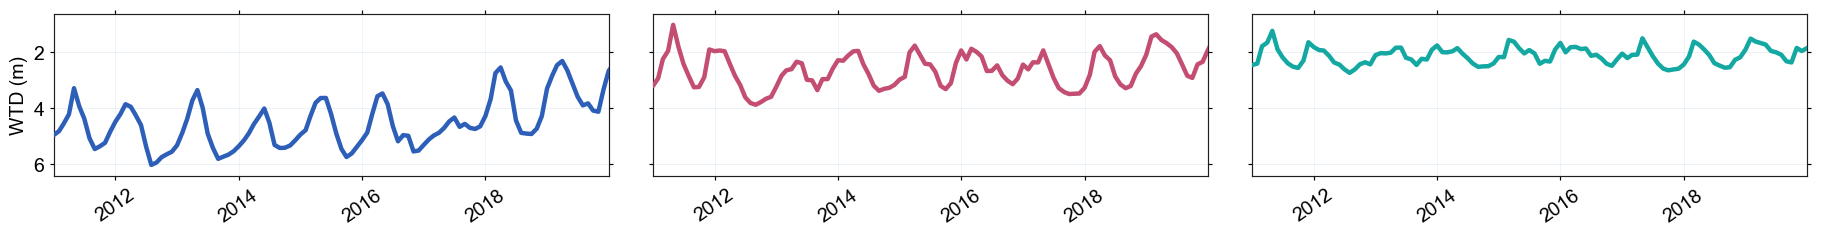

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        if (p / 'outputs' / 'RECON_MAIN_2011_2023').exists():
            return p
    raise FileNotFoundError('Could not find repository root from current working directory.')


ROOT = find_repo_root()
FIG3_SOURCE_DIR = ROOT / 'outputs' / 'figures' / 'Fig3' / 'source_data'
CLUSTER_LABELS_CSV = ROOT / 'outputs' / 'RECON_MAIN_2011_2023' / 'metrics' / 'clustering' / 'cluster_labels.csv'
OUT_DIR = ROOT / 'outputs' / 'figures' / 'Fig3'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TIMESERIES_CSV = FIG3_SOURCE_DIR / 'fig3c_wtd_timeseries.csv'
SITES_CSV = FIG3_SOURCE_DIR / 'fig3_selected_sites.csv'
OUT_PNG = OUT_DIR / 'Fig3c_WTD.png'

TARGET_GRID_IDS = [45679, 83836, 84953]
TARGET_EXPECTED_CLASSES = ['Fast recovery', 'Slow recovery', 'Buffered']
CLASS_COLORS = {
    'Fast recovery': '#2D5FB8',
    'Slow recovery': '#C44E72',
    'Buffered': '#13A8A2',
}

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'font.size': 8.5,
    'axes.labelsize': 14,
    'axes.titlesize': 9.5,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 8.5,
    'axes.linewidth': 0.85,
    'xtick.major.width': 0.85,
    'ytick.major.width': 0.85,
    'xtick.major.size': 3.2,
    'ytick.major.size': 3.2,
})

ts = pd.read_csv(TIMESERIES_CSV)
sites = pd.read_csv(SITES_CSV)
labels = pd.read_csv(
    CLUSTER_LABELS_CSV,
    usecols=['grid_id', 'response_class', 'best_score', 'score_margin'],
)

target_labels = labels[labels['grid_id'].isin(TARGET_GRID_IDS)].copy()
if len(target_labels) != len(TARGET_GRID_IDS):
    missing_ids = sorted(set(TARGET_GRID_IDS) - set(target_labels['grid_id']))
    raise ValueError(f'Target grid ids are missing from current cluster labels: {missing_ids}')

target_labels['grid_id'] = pd.Categorical(target_labels['grid_id'], categories=TARGET_GRID_IDS, ordered=True)
target_labels = target_labels.sort_values('grid_id').reset_index(drop=True)
target_labels['expected_class'] = TARGET_EXPECTED_CLASSES
if not (target_labels['response_class'].to_numpy() == target_labels['expected_class'].to_numpy()).all():
    raise ValueError('Fig3c target classes no longer match the current three-class clustering. Update TARGET_GRID_IDS before plotting.')

ts = ts[ts['grid_id'].isin(TARGET_GRID_IDS)].copy()
ts = ts.merge(target_labels[['grid_id', 'response_class']], on='grid_id', how='left')
ts['month_start'] = pd.to_datetime(ts['month_start'])
ts['grid_id'] = pd.Categorical(ts['grid_id'], categories=TARGET_GRID_IDS, ordered=True)
ts = ts.sort_values(['grid_id', 'month_start'])

sites = sites[sites['grid_id'].isin(TARGET_GRID_IDS)].copy()
sites['grid_id'] = pd.Categorical(sites['grid_id'], categories=TARGET_GRID_IDS, ordered=True)
sites = sites.sort_values('grid_id')
sites = sites.drop(columns=[c for c in ['response_class', 'best_score', 'score_margin'] if c in sites.columns])
sites = sites.merge(target_labels, on='grid_id', how='left')

print('Fig3c sites and current classes:')
print(sites[['grid_id', 'station_nm', 'response_class', 'best_score']].to_string(index=False))

values = ts[['reconstructed_wtd_m_bls']].to_numpy(dtype=float)
ymin = np.nanmin(values)
ymax = np.nanmax(values)
ypad = max(0.25, 0.08 * (ymax - ymin))
ylim = (ymax + ypad, max(0.0, ymin - ypad))

fig, axes = plt.subplots(1, 3, figsize=(18.75, 2.5), sharex=True, sharey=True)

grid_color = '#D9E9F2'
spine_color = '#1F1F1F'

for ax, grid_id in zip(axes, TARGET_GRID_IDS):
    site_ts = ts[ts['grid_id'] == grid_id]
    site = sites[sites['grid_id'] == grid_id].iloc[0]
    line_color = CLASS_COLORS.get(site['response_class'], '#2D5FB8')

    ax.plot(
        site_ts['month_start'],
        site_ts['reconstructed_wtd_m_bls'],
        color=line_color,
        lw=3.2,
        solid_capstyle='round',
        label='Reconstruction',
        zorder=3,
    )
    ax.set_ylim(*ylim)
    ax.grid(True, axis='y', color=grid_color, lw=0.55, alpha=0.72, zorder=1)
    ax.grid(True, axis='x', color=grid_color, lw=0.50, alpha=0.62, zorder=1)
    ax.tick_params(direction='out', top=True, right=True)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.85)
        spine.set_color(spine_color)

axes[0].set_ylabel('WTD (m)')
for ax in axes:
    ax.set_xlim(pd.Timestamp('2011-01-01'), pd.Timestamp('2019-12-31'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=35)

fig.subplots_adjust(left=0.060, right=0.995, bottom=0.31, top=0.96, wspace=0.08)
fig.savefig(OUT_PNG, dpi=600)
print(OUT_PNG.relative_to(ROOT))
